# D-Flow: Differentiating through Flows for Controlled Generation

Basic implementation of D-Flow.
[[arxiv]](https://arxiv.org/abs/2402.14017)

Code written by Heli Ben Hamu.

[website](https://helibenhamu.github.io/)

In [ ]:
!pip install torchdiffeq
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## Imports

In [ ]:
from typing import Dict, Optional, List, Tuple, Callable, Any
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchdiffeq import odeint
import time
import torch.optim as optim
from torchmetrics import CatMetric
import sklearn
import sklearn.datasets


## Helper Functions


In [ ]:
def ode_integrate(ode_func: Callable,
                  init_x: torch.Tensor,
                  ode_opts: Dict = {},
                  t_eps: float = 0,
                  init_t: float = 0.,
                  final_t: float = 1.,
                  t_arr: Optional[List[float]] = None,
                  intermediate_points: bool = False
      ) -> torch.Tensor:

    """Integrates an ODE using the given ode_func.

    Args:
        ode_func: model wraper to use for the ODE. Expected API: ode_func(t, x) -> torch.Tensor
        init_x: The initial state of the ODE.
        ode_opts: A dictionary of options for the ODE solver.
        t_eps: A small value to add to the initial time.
        init_t: The initial time.
        final_t: The final time.
        t_arr: An optional array of times to evaluate the ODE at.
        intermediate_points: Whether to return the intermediate points.

    Returns:
        The solution to the ODE at the final time. (or at intermediate points if intermediate_points=True)
    """

    if t_arr is None:
        t = torch.FloatTensor([init_t-t_eps, final_t]).to(init_x.device)
    else:
        t = torch.FloatTensor(t_arr).to(init_x.device)

    z = odeint(ode_func, init_x, t, **{"atol": 1e-5, "rtol": 1e-5, **ode_opts})
    if not intermediate_points:
        z = z[-1]
    return z

def neg_PSNR(x: torch.Tensor,
             y: torch.Tensor,
             peak_power: torch.Tensor = torch.tensor(2.)
              ):
    """Computes the negative PSNR between two tensors.

    Args:
        x: The first tensor.
        y: The second tensor.
        peak_power: The peak_power value of the tensor x. (default: torch.tensor(2.) for images with pixel values in range [-1,1])

    Returns:
        The negative PSNR between the two tensors.
    """
    MSE = (x - y).square().flatten(1).mean(-1)
    psnr = (20*torch.log10(peak_power)-10*torch.log10(MSE))
    return -psnr


def get_init_x(x_dims: torch.Size,
               ode_func: Callable,
               y: torch.Tensor,
               H: Callable,
               init_method: Any = 'random',
               ode_opts: Dict = {},
               blend_coef: float = 1.,
               init_t: float = 0.,
               final_t: float = 1.
               ):
    """Gets the initial state of the ODE.

    Args:
        x_dims: The dimensions of the initial state.
        ode_func: model wraper to use for the ODE. Expected API: ode_func(t, x) -> torch.Tensor
        y: observed signal / control value
        H: forward operator
        init_method: The method to use to initialize the initial state. (default: 'random')
                      'random'        - init_x ~ N(0,I)
                      'backward'      - init_x = ODEsolve(y, [1,0])
                      'backward_blend'- init_x = H(ODEsolve(y, [1,0]))*sqrt(blend_coef) + z*sqrt(1-blend_coef) , z~N(0,I)
                      int             - init_x = torch.randn(x_dims) with seed = init_method
        ode_opts: A dictionary of options for the ODE solver.
        blend_coef: The blend coefficient for the initial state.
        init_t: The initial time.  (default: 0.)
        final_t: The final time.  (default: 1.)

    Returns:
        The initial state of the ODE.
    """

    if init_method == 'random':
        init_x = torch.randn(x_dims).to(y)

    elif init_method == 'backward' or init_method == 'backward_blend':
        print('solve back')
        with torch.no_grad():
            # when solving back, y needs to have same shape as x_dims.
            # For example, when H is a downsampling operator, one needs to pass an upsampled version of y:
            # y_upsampled = F.interpolate(y, scale_factor=scale_factor, mode='bicubic')
            init_x = ode_integrate(ode_func, y, ode_opts, init_t=final_t, final_t=init_t) # note we solve backward

        if init_method == 'backward_blend':
            noise = torch.randn(x_dims).to(y)
            init_x = init_x * np.sqrt(blend_coef) + noise * np.sqrt(1-blend_coef)
    elif type(init_method) is int:
        torch.manual_seed(init_method)
        init_x = torch.randn(x_dims).to(y)
    else:
        raise ValueError(f"Uknown init_method {init_method}")
    return init_x

## Train a flow model

### Model Architecture

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sigmoid(x)*x


class MLP(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers):
    super(MLP, self).__init__()

    self.num_layers = num_layers
    self.layers = nn.ModuleList()

    self.layers.append(nn.Linear(input_size, hidden_size))
    for i in range(self.num_layers-2):
        self.layers.append(nn.Linear(hidden_size, hidden_size))
    self.layers.append(nn.Linear(hidden_size, output_size))

    self.act = Swish()

  def forward(self, x, t):
    x = torch.cat([t, x],dim=1)
    for i in range(self.num_layers-1):
      x = self.act(self.layers[i](x))
    out = self.layers[-1](x)
    return out


### Model and Optimizer


In [ ]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(f'using device {device}')
model = MLP(input_size=3,hidden_size=256,output_size=2,num_layers=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)

# Dataset iterator
def inf_train_gen(batch_size=200):
    data = sklearn.datasets.make_circles(n_samples=batch_size, factor=.5, noise=0.03)[0]
    data = data.astype("float32")
    return data




using device cuda


### Training Loop

In [ ]:
n_iters = 15000
batch_size = 10000

for iter in range(n_iters):

    optimizer.zero_grad()

    # sample t~U[0,1]
    t = torch.rand((batch_size,1)).to(device)

    # sample x0~p
    x0 = torch.randn((batch_size,2)).to(device)

    # sample x1~q
    x1 = torch.tensor(inf_train_gen(batch_size)).to(device)

    # compute conditional flow
    # xt = psi_t(x0|x1) = sigma_t*x0 + alpha_t*x1
    xt = (1-t)*x0 + t*x1

    # compute conditional velocity
    # u_t(x|x1) = dsigma_t/dt*x0 + dalpha_t/dt*x1
    ut = x1-x0

    # forward
    vt = model(xt,t)

    # loss
    loss = (vt - ut).pow(2).mean()

    # optimize
    loss.backward()
    optimizer.step()
    scheduler.step()

    if iter % 1000 == 0:
        print(f'finished {iter} iterations, loss: {loss}')



finished 0 iterations, loss: 1.3093700408935547
finished 1000 iterations, loss: 0.8606509566307068
finished 2000 iterations, loss: 0.8481748104095459
finished 3000 iterations, loss: 0.834480345249176
finished 4000 iterations, loss: 0.8219910860061646
finished 5000 iterations, loss: 0.800749659538269
finished 6000 iterations, loss: 0.821357786655426
finished 7000 iterations, loss: 0.8246747851371765
finished 8000 iterations, loss: 0.805768609046936
finished 9000 iterations, loss: 0.8197994828224182
finished 10000 iterations, loss: 0.8189592361450195
finished 11000 iterations, loss: 0.8140065670013428
finished 12000 iterations, loss: 0.8203421831130981
finished 13000 iterations, loss: 0.8064308166503906
finished 14000 iterations, loss: 0.8198080658912659


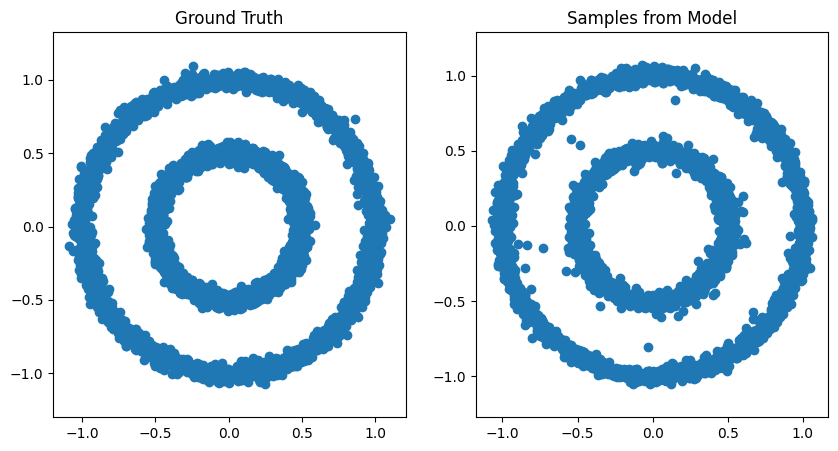

In [ ]:
num_samples=5000
x0 = torch.randn((num_samples,2)).to(device)
t = torch.zeros((num_samples,1)).to(device)

# number of discretization steps
N = 100
xt = x0

for i in range(N):
    xt = xt + model(xt,t)* (1/N)
    t  = t + 1/N

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plt.subplot(1, 2, 1)
x_data = torch.tensor(inf_train_gen(num_samples))

plt.scatter(x_data[:,0].cpu().detach().numpy(),x_data[:,1].cpu().detach().numpy())
plt.axis('equal')
plt.title('Ground Truth')

plt.subplot(1, 2, 2)
plt.scatter(xt[:,0].cpu().detach().numpy(),xt[:,1].cpu().detach().numpy())
plt.axis('equal')
plt.title('Samples from Model')
plt.show()



## D-Flow Sampler

In [ ]:
def dflow(ode_func: Callable,
          y: torch.Tensor,
          H: Callable,
          cost_func: Callable,
          x_dims: torch.Size,
          init_method: Any ='random',
          init_ode_opts: Dict ={"method": "midpoint", "options": {"step_size":0.02}},
          blend_coef: float = 1.,
          ode_opts: Dict = {},
          optimizer_type: str = 'LBFGS',
          lr: float = 1.,
          optim_steps: int = 30,
          max_iter: int = 20,
          regularizer: Any = None,
          reg_lam: float = 0.,
          target_cost: float = None,
          time_limit: float = None,
          t_range=[0,1]
      ):
    """Samples a solution to the ODE using D-Flow.

    Args:
        ode_func: model wraper to use for the ODE. Expected API: ode_func(t, x) -> torch.Tensor
        y: observed signal / control value
        H: forward operator
        cost_func: cost function to minimize
        x_dims: The dimensions of the initial state.
        init_method: The method to use to initialize the initial state.
        init_ode_opts: A dictionary of options for the ODE solver.
        blend_coef: The blend coefficient for the initial state.
        ode_opts: A dictionary of options for the ODE solver.
        lr: The learning rate for the optimizer.
        optim_steps: The number of optimization steps to perform.
        max_iter: The maximum number of iterations for the optimizer.
        regularizer: The type of regularizer to use.
        reg_lam: The regularization strength.
        target_cost: The target cost to reach.
        time_limit: The time limit for the optimization.
        t_range: The time range for the integration in the optimization.

    Returns:
        The solution to the ODE at the final time.
    """

    loss = 0
    start_time = time.time()

    init_t = t_range[0]
    final_t = t_range[-1]

    init_x = get_init_x(x_dims, ode_func, y, H, init_method, init_ode_opts, blend_coef, init_t, final_t)
    init_x.requires_grad_(True)

    x1_trajectory = []
    x1 = ode_integrate(ode_func, init_x, ode_opts, init_t=init_t, final_t=final_t)
    x1_trajectory.append(x1.detach().cpu().numpy())

    if optimizer_type == 'LBFGS':
      optimizer = optim.LBFGS([init_x], max_iter=max_iter, lr=lr, line_search_fn='strong_wolfe')
    elif optimizer_type == 'SGD':
      optimizer = torch.optim.SGD([init_x], lr=lr)
    else:
      raise ValueError(f"Uknown optimizer_type {optimizer_type}")


    metrics = {'loss': CatMetric(), 'cost': CatMetric(), 'reg': CatMetric(), 'norm_x0': CatMetric(), 'std_x0': CatMetric(), 'mean_x0': CatMetric(), 'time': CatMetric()}
    for step in range(optim_steps):

        def closure():
            nonlocal loss
            nonlocal x1
            optimizer.zero_grad()

            reg_loss = torch.tensor(0.).to(init_x)

            ### solve for x1
            x1 = ode_integrate(ode_func, init_x, ode_opts, init_t=init_t, final_t=final_t)

            ### set or compute regularization loss
            if regularizer == 'chi_d':
                dim_x = torch.tensor(init_x[0].numel()).to(init_x)
                init_x_norm = init_x.norm()
                reg_loss = -((dim_x-1)*torch.log(init_x_norm) - init_x_norm.pow(2)/2)

            degraded_x1 = H(x1)
            cost = cost_func(degraded_x1, y)
            loss = cost + reg_lam * reg_loss

            norm_x0 = init_x.norm()
            std_x0 = init_x.std()
            mean_x0 = init_x.mean()

            metrics['norm_x0'].update(norm_x0.item())
            metrics['std_x0'].update(std_x0.item())
            metrics['mean_x0'].update(mean_x0.item())
            metrics['cost'].update(cost.item())
            metrics['reg'].update(reg_loss.item())
            metrics['loss'].update(loss.item())

            loss.backward()

            return loss

        if optimizer_type == 'LBFGS':
          optimizer.step(closure)
        elif optimizer_type == 'SGD':
          loss = closure()
          optimizer.step()

        x1_trajectory.append(x1.detach().cpu().numpy())


        elapsed = time.time() - start_time
        metrics['time'].update(elapsed)

        if step % 5 == 0:
            elapsed = elapsed/60
            print(f"[Step {step}] Loss {loss.item()}"
              + f"| x_init min {init_x.detach().min()} max {init_x.detach().max()}" + f"| time: {elapsed} mins")


        if target_cost is not None:
            mets_cost = metrics['cost'].compute()
            if mets_cost.dim() > 0:
                mets_cost = mets_cost[-1]
            last_cost = mets_cost.item()
            if last_cost <= target_cost:
                print(f'reached cost of {last_cost}')
                break

        if time_limit is not None:
            elapsed = (time.time() - start_time)/60 # time in minutes
            if elapsed > time_limit:
                print(f'reached time limit of {time_limit} mins')
                break

    with torch.no_grad():
       x1 = ode_integrate(ode_func, init_x, ode_opts, init_t=init_t, final_t=final_t)
    x1_trajectory.append(x1.detach().cpu().numpy())

    return x1, x1_trajectory, metrics




## Optimize with D-Flow

In [ ]:
def Angle(x: torch.Tensor):
    """ computes the angle of a point x
    Args:
        x: a point in 2D
    Returns:
        the angle of the point
    """
    return torch.atan2(x[:,1], x[:,0])


def MSE_cost(x: torch.Tensor, y: torch.Tensor):
    """ computes the mean squared error between two tensors
    Args:
        x: a tensor
        y: a tensor
    Returns:
        the mean squared error between the two tensors
    """
    return (x-y).pow(2).mean()


def ode_func(t,x):
    return model(x,t.repeat(x.shape[0]).unsqueeze(1))


# Optimize with D-Flow to sample from a given angle value y
# We are using SGD instead of LBFGS here since LBFGS converges very fast,
# and we want to visualize the optimization dynamics.
y = 1.4
d_flow_sample = dflow(ode_func = ode_func,
                      y = torch.tensor(y).to(device),
                      H = Angle,
                      cost_func = MSE_cost,
                      x_dims = (1,2),
                      optimizer_type = 'SGD',
                      lr = 0.1,
                      ode_opts = {"method": "midpoint", "options": {"step_size":0.1}},
                      optim_steps = 1000,
                      max_iter = 1,
                      target_cost=1e-4
                      )



[Step 0] Loss 18.842432022094727| x_init min -1.636309266090393 max -0.8113850355148315| time: 0.00732271671295166 mins
[Step 5] Loss 10.700098991394043| x_init min -1.9778931140899658 max -0.24783699214458466| time: 0.011156876881917318 mins
[Step 10] Loss 6.418454170227051| x_init min -1.778669834136963 max 1.0932154655456543| time: 0.013680132230122884 mins
[Step 15] Loss 4.112329006195068| x_init min -1.0867160558700562 max 1.8472487926483154| time: 0.0160733699798584 mins
[Step 20] Loss 2.6222150325775146| x_init min -0.3226929008960724 max 2.1718335151672363| time: 0.018649347623189292 mins
[Step 25] Loss 1.7358062267303467| x_init min 0.3127861022949219 max 2.204965829849243| time: 0.022743781407674152 mins
[Step 30] Loss 1.1579629182815552| x_init min 0.8194248080253601 max 2.0796308517456055| time: 0.026471849282582602 mins
[Step 35] Loss 0.7571244835853577| x_init min 1.20570969581604 max 1.8860033750534058| time: 0.029915122191111247 mins
[Step 40] Loss 0.5002830624580383| x

In [ ]:
x_data = torch.tensor(inf_train_gen(num_samples))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150
plt.ioff()

traj = d_flow_sample[1]

fig, ax = plt.subplots(figsize=(3, 3))
def animate(i):
    ax.cla()
    ax.scatter(x_data[:,0].cpu().detach().numpy(),x_data[:,1].cpu().detach().numpy())
    # draw an angle with x axis and annotate it with the y value
    ax.arrow(0, 0, np.cos(y), np.sin(y), head_width=0.05, head_length=0.1, fc='k', ec='k')
    ax.text(0.02, 0.02, f'y = {y:.2f}', transform=ax.transAxes)
    ax.axis('equal')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_title(f'Iteration {i}, Angle {Angle(torch.tensor(traj[i])).item():.2f}')


    ax.scatter(traj[i][:,0],traj[i][:,1])
    ax.axis('equal')
    return fig
ani = animation.FuncAnimation(fig, animate, frames=len(traj))
display(ani)